### Traitement des données : Dans cette partie, il s'agira pour nous de préparer les données pour la modélisation à travers le nettoyage, l'encodage et le feature engineering

In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.preprocessing import OrdinalEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
import os
os.listdir("../data/raw")

['smart_city_traffic_stress_dataset.csv']

In [3]:
# Loading the dataset
data = pd.read_csv("../data/raw/smart_city_traffic_stress_dataset.csv")

In [4]:
# Types of columns in the dataset
data.dtypes

traffic_density              int64
horn_events_per_min        float64
avg_speed                  float64
signal_wait_time           float64
weather_condition           object
road_quality_score         float64
driver_experience_level     object
stress_index               float64
dtype: object

In [5]:
# Checking missing values
data.isnull().sum()

traffic_density            0
horn_events_per_min        0
avg_speed                  0
signal_wait_time           0
weather_condition          0
road_quality_score         0
driver_experience_level    0
stress_index               0
dtype: int64

In [6]:
# Visualization of the first 3 rows of the dataset 
data.head(3)

,traffic_density,horn_events_per_min,avg_speed,signal_wait_time,weather_condition,road_quality_score,driver_experience_level,stress_index
0,112,12.93,28.61,56.58,Foggy,7.31,Intermediate,68.37
1,61,7.43,54.22,35.64,Rainy,8.78,Beginner,47.14
2,102,11.07,41.42,54.61,Clear,8.34,Intermediate,55.02


In [7]:
# Checking for duplicates
print(data.duplicated().sum())

0


### Encodage

In [8]:
# Encoding categorical variable driver_experience_level with OrdinalEncoder
oe = OrdinalEncoder(categories=[['Beginner', 'Intermediate', 'Expert']])
data['driver_experience_encoded'] = oe.fit_transform(data[['driver_experience_level']])
data.drop(columns=['driver_experience_level'], inplace=True)

# Verification
print(data[['driver_experience_encoded']].value_counts().sort_index())

driver_experience_encoded
0.0                          14872
1.0                          24980
2.0                          10148
Name: count, dtype: int64


In [9]:
# Encoding categorical variable weather_condition with One-Hot Encoding
data = pd.get_dummies(data, columns=['weather_condition'], prefix='weather', drop_first=True)

# Verification
weather_cols = [c for c in data.columns if c.startswith('weather_')]
data[weather_cols] = data[weather_cols].astype(int)
print(data[weather_cols].head())
print(data[weather_cols].value_counts())

   weather_Foggy  weather_Hot  weather_Rainy
0              1            0              0
1              0            0              1
2              0            0              0
3              0            0              0
4              0            0              0
weather_Foggy  weather_Hot  weather_Rainy
0              0            0                25018
                            1                12283
1              0            0                 7615
0              1            0                 5084
Name: count, dtype: int64


In [10]:
# Global verification
print(f"Shape before encoding: (50000, 8)")
print(f"Shape after encoding: {data.shape}")
print("\nFinal columns:")
print(data.dtypes)

Shape before encoding: (50000, 8)
Shape after encoding: (50000, 10)

Final columns:
traffic_density                int64
horn_events_per_min          float64
avg_speed                    float64
signal_wait_time             float64
road_quality_score           float64
stress_index                 float64
driver_experience_encoded    float64
weather_Foggy                  int64
weather_Hot                    int64
weather_Rainy                  int64
dtype: object


In [11]:
# Correlations of new features with stress_index
new_features = ['driver_experience_encoded', 'weather_Foggy', 'weather_Hot', 'weather_Rainy']
print("Correlations with stress_index:")
print(data[new_features + ['stress_index']].corr()['stress_index'].sort_values(ascending=False).round(3))

Correlations with stress_index:
stress_index                 1.000
weather_Foggy                0.012
weather_Rainy                0.010
weather_Hot                 -0.003
driver_experience_encoded   -0.325
Name: stress_index, dtype: float64


### Feature Engineering

In [12]:
# 1. Congestion score — interaction density × wait time
# Captures truly blocked situations (dense AND long wait)
data['congestion_score'] = (data['traffic_density'] * data['signal_wait_time']) / 100

# 2. Horn density — horns relative to density
# Measures aggressive driver behavior, not raw volume
data['horn_density'] = data['horn_events_per_min'] / (data['traffic_density'] + 1)

# 3. Speed efficiency — speed relative to density
# Detects anomalies: speed too high or too low for observed density
data['speed_efficiency'] = data['avg_speed'] / (data['traffic_density'] + 1)

In [13]:
# Global verification
print(f"Shape before feature engineering: (50000, 10)")
print(f"Shape after feature engineering: {data.shape}")
print("\nFinal columns:")
print(data.dtypes)

Shape before feature engineering: (50000, 10)
Shape after feature engineering: (50000, 13)

Final columns:
traffic_density                int64
horn_events_per_min          float64
avg_speed                    float64
signal_wait_time             float64
road_quality_score           float64
stress_index                 float64
driver_experience_encoded    float64
weather_Foggy                  int64
weather_Hot                    int64
weather_Rainy                  int64
congestion_score             float64
horn_density                 float64
speed_efficiency             float64
dtype: object


In [14]:
# Correlations of new features with stress_index
new_features = ['congestion_score', 'horn_density', 'speed_efficiency']
print("Correlations with stress_index:")
print(data[new_features + ['stress_index']].corr()['stress_index'].sort_values(ascending=False).round(3))

Correlations with stress_index:
stress_index        1.000
congestion_score    0.835
horn_density       -0.169
speed_efficiency   -0.705
Name: stress_index, dtype: float64


### Multicollinearity Adjustments

In [15]:
# VIF of Numerical Features
def compute_vif(df):
    vif = pd.DataFrame()
    vif['feature'] = df.columns
    vif['VIF'] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif.sort_values('VIF', ascending=False).round(2)

# Numerical Features before feature engineering
num_features = ['traffic_density', 'horn_events_per_min', 'avg_speed', 'signal_wait_time', 'road_quality_score', 'driver_experience_encoded']
all_features = num_features + ['congestion_score', 'horn_density', 'speed_efficiency']

print("\n================ VIF ================")
print(compute_vif(data[all_features]))


================ VIF ================
                     feature     VIF
0            traffic_density  269.48
3           signal_wait_time  239.24
6           congestion_score  135.72
2                  avg_speed   74.34
1        horn_events_per_min   39.19
4         road_quality_score   16.59
8           speed_efficiency   15.53
7               horn_density   15.27
5  driver_experience_encoded    2.66


In [16]:
# Dropping original features
features_to_drop = ['horn_events_per_min', 'signal_wait_time', 'traffic_density']
data.drop(columns=features_to_drop, inplace=True)

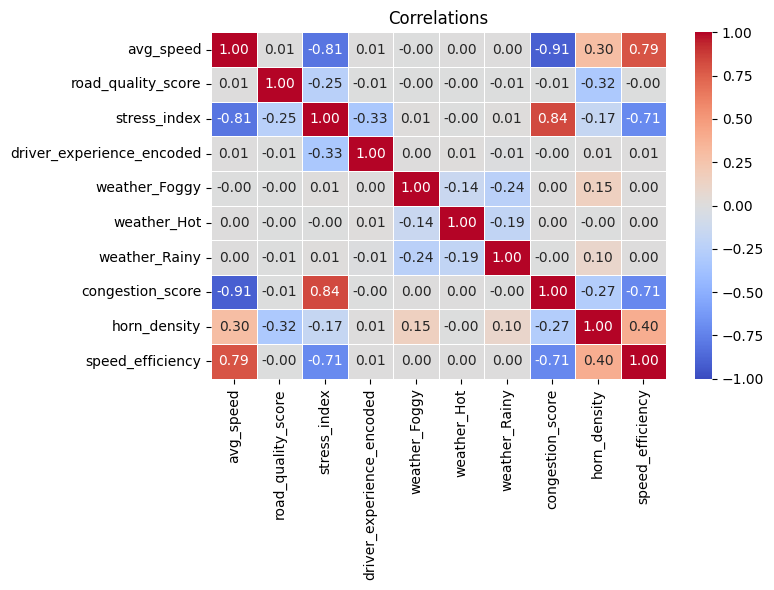

In [17]:
# Correlation Heatmap for verification
plt.figure(figsize=(8, 6))
corr = data.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlations')
plt.tight_layout()
plt.savefig('../results/figures/correlation_after_vif.png', dpi=150)
plt.show()

In [18]:
# Split the dataset to prepare modeling for linear vs tree-based models
data_lin = data.drop(columns=['avg_speed', 'speed_efficiency', 'weather_Foggy', 'weather_Hot', 'weather_Rainy', 'horn_density'])
data_boost = data.drop(columns=['speed_efficiency'])

In [19]:
# VIF after removing redundant features
remaining = ['avg_speed', 'road_quality_score', 'driver_experience_encoded',
             'congestion_score', 'horn_density', 'speed_efficiency']
print("=== VIF after removal ===")
print(compute_vif(data[remaining]))
# Expected: road_quality_score should be below 5

=== VIF after removal ===
                     feature    VIF
0                  avg_speed  23.09
1         road_quality_score  14.69
4               horn_density   6.17
5           speed_efficiency   5.21
3           congestion_score   4.25
2  driver_experience_encoded   2.65


##### === VIF DECISION for data_boost ===

avg_speed        VIF=23.09  -> high BUT accepted
road_quality     VIF=14.69  -> high BUT accepted

Reason: data_boost is for tree-based models
(RandomForest, XGBoost, LightGBM).

These models make independent binary splits at each node -
they don't calculate coefficients like linear regression.
Multicollinearity doesn't bias their predictions, it only reduces
the stability of feature importance (two correlated features
"share" the importance) but doesn't affect R².

-> Strict VIF (< 5) is a constraint for regression ONLY.
-> For data_boost: VIF is informative only, not blocking.

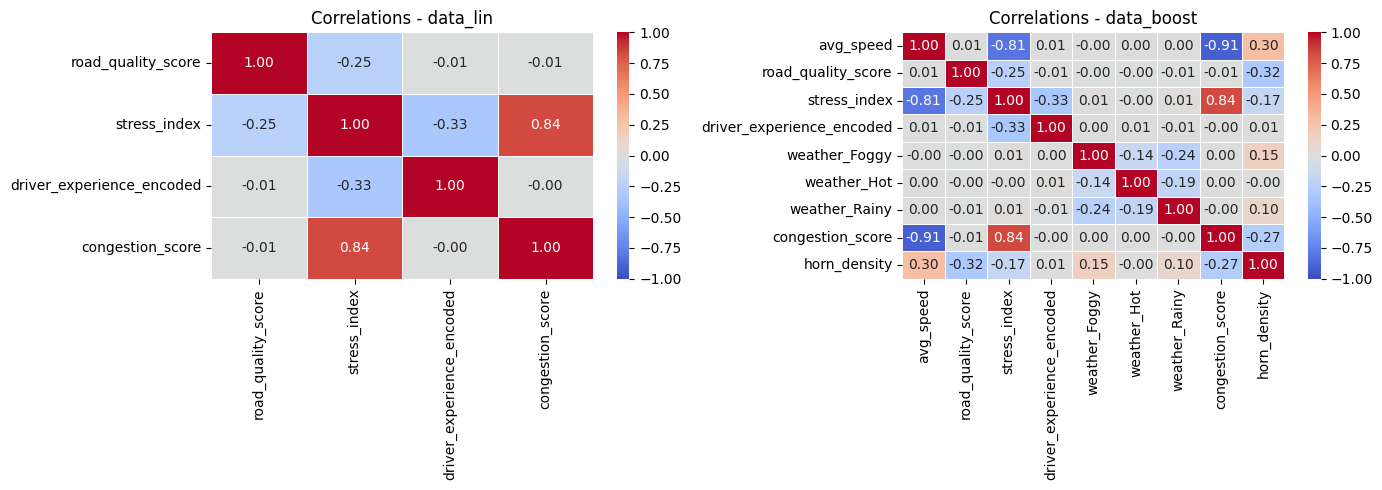

In [20]:
# Final correlations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap for data_lin
corr_lin = data_lin.corr()
sns.heatmap(corr_lin, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Correlations - data_lin', fontsize=12)

# Heatmap for data_boost
corr_boost = data_boost.corr()
sns.heatmap(corr_boost, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Correlations - data_boost', fontsize=12)

plt.tight_layout()
plt.savefig('../results/figures/correlation_lin_vs_boost.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# VIF for data_lin
data_lin_features = ['congestion_score', 'driver_experience_encoded', 'road_quality_score']
print(compute_vif(data_lin[data_lin_features]))

                     feature   VIF
2         road_quality_score  3.50
1  driver_experience_encoded  2.41
0           congestion_score  2.40


In [22]:
# Save the ordinal encoder for driver_experience_level to encode new data
with open("../models/ordinal_encoder.pkl", "wb") as f:
    pickle.dump(oe, f)
print("ordinal_encoder.pkl saved for driver_experience_level.")

ordinal_encoder.pkl saved for driver_experience_level.


In [23]:
# Save processed datasets
data_lin.to_csv("../data/processed/smart-city-traffic-stress-index-dataset_clean_lin.csv", index=False)
data_boost.to_csv("../data/processed/smart-city-traffic-stress-index-dataset_clean_boost.csv", index=False)
print("Processed datasets saved!")

Processed datasets saved!


### **Conclusion**

 **ENCODAGE**   
  ✓  driver_experience_level -> OrdinalEncoder (0=Beginner, 1=Inter, 2=Expert)  
  ✓  weather_condition       -> One-Hot (drop_first=True -> 3 colonnes int)  
 
 **FEATURE ENGINEERING**   
  ✓  congestion_score  = traffic_density × signal_wait_time / 100 -> r=+0.835  
  ~  horn_density      = horn/density                              -> r=-0.169  
  ~  speed_efficiency  = avg_speed/density                         -> r=-0.705  
  ->  congestion_score retenu comme feature composite principale   

 **MULTICOLINÉARITÉ (VIF)**  
  Supprimées : traffic_density, signal_wait_time, horn_events_per_min   
  data_lin VIF : congestion=2.40, experience=2.41, road_quality=3.50   

 **DATASETS FINAUX**   
  **data_lin (50000 × 4)** : congestion_score, driver_experience, road_quality_score + stress_index  
  **data_boost (50000 × 9)** : congestion_score, driver_experience, road_quality_score, avg_speed, horn_density, weather_* + stress_index    

 **PROCHAINE ÉTAPE : MODÉLISATION**   
  Le notebook 03_modeling.ipynb entraînera et comparera :  
  • LinearRegression     sur data_lin  (benchmark)  
  • RandomForest         sur data_boost  
  • XGBoost              sur data_boost  
  • LightGBM             sur data_boost  
  Évaluation via RMSE, MAE, R² 